In [1]:
import rasterio
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

In [ ]:
# month = '8'
# with rasterio.open(f"/Users/cherryleheu/Documents/HCDP/Data/climo/monthly/rainfall/monthly_rainfall_clim_statewide_1991-2020_{month}.tif") as src:
#     rf_climo = src.read(1)
#     nodata_climo = src.nodata
#     meta = src.meta.copy()

# masked_climo = np.ma.masked_equal(rf_climo, nodata_climo)

# with rasterio.open(f"../public/tifs/rainfall_2025_0{month}.tif") as src:
#     rf = src.read(1)
#     nodata_rf = src.nodata
#     transform = src.transform

# masked_rf = np.ma.masked_equal(rf, nodata_rf)

# pdiff = (masked_rf - masked_climo) / masked_climo * 100

# combined_mask = np.ma.getmask(masked_rf) | np.ma.getmask(masked_climo)
# pdiff_masked = np.ma.array(pdiff, mask=combined_mask)

# out_nodata = -9999 
# meta.update(
#     dtype="float32",
#     nodata=out_nodata
# )

# with rasterio.open(f"../public/tifs/pdiff_2025_0{month}.tif", "w", **meta) as dst:
#     dst.write(pdiff_masked.filled(out_nodata).astype("float32"), 1)


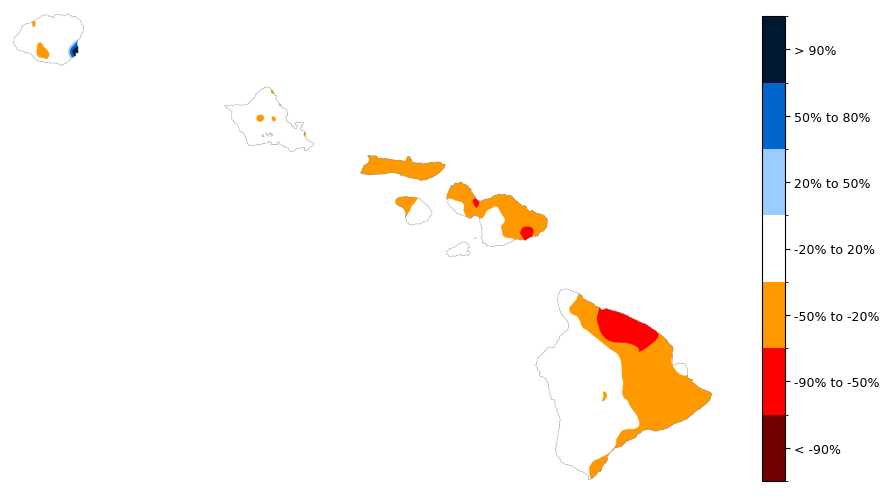

In [4]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

thresholds = [
    (-np.inf, -80, "#730000", "< -90%"),
    (-80, -50, "#FF0000", "-90% to -50%"),
    (-50, -30, "#FF9900", "-50% to -20%"),
    (-30, 30, "#FFFFFF", "-20% to 20%"),
    (30, 50, "#99CCFF", "20% to 50%"),
    (50, 80, "#0066CC", "50% to 80%"),
    (80, np.inf, "#001933", "> 90%"),
]

with rasterio.open(f"annual_rainfall_2025_pdiff.tif") as src:
    data = src.read(1)
    profile = src.profile
    nodata = src.nodata

data = np.where(data == nodata, np.nan, data)
categorical = np.full_like(data, 255, dtype=np.uint8)

for i, (low, high, _, _) in enumerate(thresholds):
    mask = (data > low) & (data <= high)
    categorical[mask] = i

profile.update(dtype=rasterio.uint8, count=1, compress='lzw', nodata=255)
# with rasterio.open(f"../public/tifs/rf_pdiff_cat_0{month}.tif", "w", **profile) as dst:
#     dst.write(categorical, 1)

colors = [c for _, _, c, _ in thresholds]
labels = [l for _, _, _, l in thresholds]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

plt.figure(figsize=(9, 6))
categorical_masked = np.ma.masked_where(categorical == 255, categorical)

im = plt.imshow(categorical_masked, cmap=cmap, norm=norm)
plt.axis("off")

cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
cbar.set_ticks(range(len(colors)))
cbar.set_ticklabels(labels)
cbar.ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()
